# Mnist decision tree:

In [57]:
import sklearn
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [58]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X, y = mnist["data"], mnist["target"]
X = X.values.astype(np.uint8)
y = y.values.astype(np.uint8)

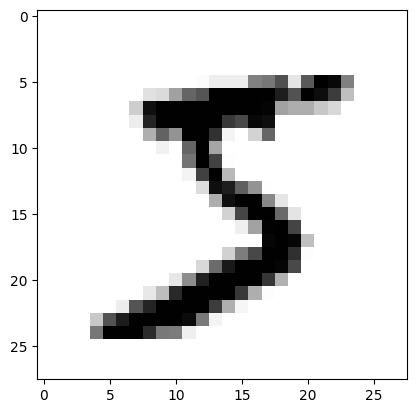

In [59]:
img_sample = X[0].reshape(28, 28)
plt.imshow(img_sample, cmap='binary')
plt.show()

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.ensemble import RandomForestClassifier

gb_clf = RandomForestClassifier()
gb_clf.fit(X_train, y_train)
y_pred = gb_clf.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9669


In [62]:
import joblib

joblib.dump(gb_clf, 'models/sklearn/RandomForest.pkl')

['models/sklearn/RandomForest.pkl']

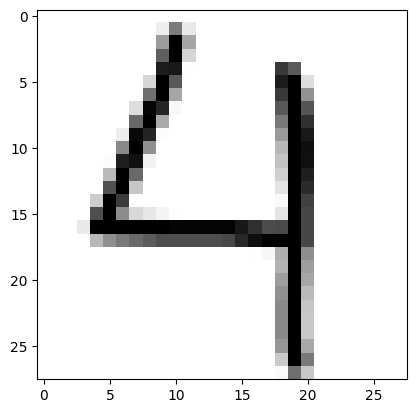

In [ ]:
img = cv.imread("received_image.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img = cv.bitwise_not(img)

thress = cv.threshold(img, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)[1]
contour = cv.findContours(thress, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)[0]
x, y, w, h = cv.boundingRect(contour[0])
img = img[y:y+h, x:x+w]
img = cv.resize(img, (28, 28), interpolation=cv.INTER_AREA)
plt.imshow(img, cmap='binary')
plt.show()

In [64]:
img_flattened = img_resized.flatten().reshape(1, -1)
model = joblib.load('models/sklearn/random_forest.pkl')
prediction = model.predict_proba(img_flattened)
print(prediction)

[[0.02 0.01 0.05 0.01 0.7  0.03 0.06 0.03 0.01 0.08]]


In [65]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_clf = HistGradientBoostingClassifier()
gb_clf.fit(X_train, y_train)
y_pred = gb_clf.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9761


In [66]:
import joblib

joblib.dump(gb_clf, 'models/sklearn/HistGradientBoosting.pkl')

['models/sklearn/HistGradientBoosting.pkl']

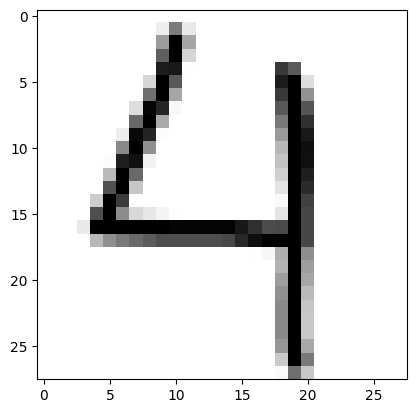

In [67]:
img = cv.imread("received_image.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img = cv.bitwise_not(img)
img_resized = cv.resize(img, (28, 28), interpolation=cv.INTER_AREA)

plt.imshow(img_resized, cmap='binary')
plt.show()

In [68]:
img_flattened = img_resized.flatten().reshape(1, -1)
model = joblib.load('models/sklearn/random_forest.pkl')
prediction = model.predict_proba(img_flattened)
print(prediction)

[[0.02 0.01 0.05 0.01 0.7  0.03 0.06 0.03 0.01 0.08]]
